# Modelling

Date: 12/03/2026

This notebook is used for modelling and processing data which has been anaylsed in the EDA notebook. We will preprocess the data, select features and test models with hyperparamter tuning. 

Model Progression:

1. Dummy classifier - baseline
2. Decision Tree - simple, interpretable
3. Random Forest - more powerful ensemble 
4. XGBoost - complex, often best performance 

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [4]:
df_clean = pd.read_csv('../data/processed/df_clean.csv') # import our cleaned data

In [5]:
X = df_clean.drop(columns=['DEFAULT']) # remove target from out features
y = df_clean['DEFAULT'] 


print('X shape: ', X.shape)
print('y shape: ', y.shape)

X shape:  (29601, 23)
y shape:  (29601,)


We split our data into training and testing sample with a test_size of 0.2. This leaves around 5,921 instances for testing enough to meaningfully evaluate recall and other metrics. We use stratify=y here to ensure the training sample is representative of the total data set class balance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

In [7]:
y_train.describe()

count    23680.000000
mean         0.223142
std          0.416362
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEFAULT, dtype: float64

In [8]:
X_train.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [9]:
y_train.describe()

count    23680.000000
mean         0.223142
std          0.416362
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEFAULT, dtype: float64

In [10]:
num_cols = ['LIMIT_BAL', 'AGE','BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6' ]

cat_cols = ['SEX', 'MARRIAGE']

ordinal_cols = ['EDUCATION',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']



In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

Creating the sub-pipelines. The numerical pipe with for transformed using the PowerTransformer (with method='yeo-johnson'), which handles negative values unlike a log transformation. The data is then scaled. The categories are one hot encoded and the ordinal categories are kept as they are. 

In [12]:
# numerical pipeline: PowerTransformer -> StandardScaler
num_pipe = Pipeline(steps=[
    ('power_trans', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler()),
])

# categorical pipeline: OneHotEncoder
cat_pipe = Pipeline(steps=[
    ('one_hot', OneHotEncoder())
])

In [13]:
preprocessor = ColumnTransformer(transformers=[
    ('num_pipe', num_pipe, num_cols),
    ('cat_pipe', cat_pipe, cat_cols),
    ('ordinal', 'passthrough', ordinal_cols) # ordinal columns are just passed through 
])

### Dummy Classifier

In [14]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent')

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dummy', dummy_clf)
])

In [15]:
dummy_fit = dummy_pipeline.fit(X_train, y_train)

dummy_pred = dummy_fit.predict(X_test)

In [16]:
from sklearn.metrics import classification_report

dummy_report = classification_report(y_test, dummy_pred)

/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

In [17]:
print(dummy_report)

              precision    recall  f1-score   support

           0       0.78      1.00      0.87      4600
           1       0.00      0.00      0.00      1321

    accuracy                           0.78      5921
   macro avg       0.39      0.50      0.44      5921
weighted avg       0.60      0.78      0.68      5921



We have used a dummy classifier to generate a baseline result for precision and recall. Precision, recall and f1 are all 0 for defaulters. The model never predicts a default. 

### Decision Tree Classifier

- We will look at a single Decision Tree to start with. It is simple to interpret and debug

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=13)

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('decision_tree', dt_clf)
])

In [19]:
dt_fit = dt_pipeline.fit(X_train, y_train)
dt_predict = dt_fit.predict(X_test)

dt_report = classification_report(y_test, dt_predict)

print(dt_report)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4600
           1       0.39      0.42      0.41      1321

    accuracy                           0.73      5921
   macro avg       0.61      0.62      0.61      5921
weighted avg       0.73      0.73      0.73      5921



Recall for defaulters went from 0 to 0.42. This means the model is now catching 42% of actual defaulters. Accuracy has gone down slightly as the decision tree is now predicting some class 1's, which means it's getting some class 0's wrong. This reducing accuracy but the recall trade-off is far more important. 


### Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=13)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', rf_clf)
])

In [21]:
rf_fit = rf_pipeline.fit(X_train, y_train)
rf_predict = rf_fit.predict(X_test)

rf_report = classification_report(y_test, rf_predict)

print(rf_report)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4600
           1       0.65      0.40      0.50      1321

    accuracy                           0.82      5921
   macro avg       0.75      0.67      0.69      5921
weighted avg       0.80      0.82      0.80      5921



We see precision for defaulters went from 0.39 to 0.65, but recall dropped from 0.42 to 0.40. This shows the model is being more cautious - when it says someone will default, it is more right, but it is missing more actual defaulters. Although we care more about recall for this problem, the drop is only slight and the F! score improved from 0.41, to 0.50. 

### XGBoost 

In [22]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=13)

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb_clf)
])

In [23]:
xgb_fit = xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_fit.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4600
           1       0.64      0.39      0.48      1321

    accuracy                           0.81      5921
   macro avg       0.74      0.66      0.69      5921
weighted avg       0.80      0.81      0.80      5921



XGBoost is slightly worse than Random Forest on most metrics with default tuning. The table below shows a comparison of the models precision, recall and F! scores. 

|Model | Precision (1) | Recall (1) | F1 (1) |
|------|---------------|------------|--------|
|Dummy | 0.00 | 0.00 | 0.00 | 0.00|
|Decision Tree | 0.39 | 0.41 | 0.42 | 
|Random Forest | 0.65 | 0.40| 0.50|
|XGBoost | 0.64 | 0.39| 0.48|

Generate a confusion matrix for our best model so far (Random Forest Model). This will tell us how many defaulters we are missing (false negatives) vs how many non-defaulters we have wrongly flagged. Here false negatives are the most costly in order to save the business money. 

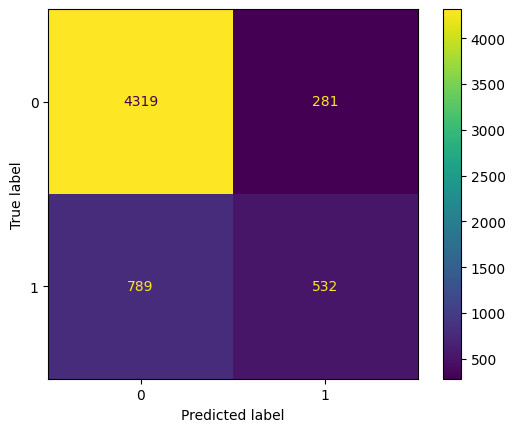

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_predict)

ConfusionMatrixDisplay(rf_cm).plot()

789 out of 1,321 actual defaulters are being missed. This is a 60% miss rate. The model is biased toward predicting class 0, so class_weight would be an important hyperparameter to explore. 

In [25]:
rf_clf_balanced = RandomForestClassifier(class_weight='balanced' ,random_state=13) 

rf_balanced_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest_bal', rf_clf_balanced)
])

# Scikit adjusts the weights of each class inversely proportional to their frequency

rf_balanced_fit = rf_balanced_pipeline.fit(X_train, y_train)

rf_balanced_pred = rf_balanced_fit.predict(X_test)

rf_balanced_report = classification_report(y_test, rf_balanced_pred)

print(rf_balanced_report)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4600
           1       0.65      0.36      0.47      1321

    accuracy                           0.81      5921
   macro avg       0.74      0.65      0.68      5921
weighted avg       0.79      0.81      0.79      5921



The recall score for class 1 has actually decreased. Therefore, class_weight=balanced is not enough on its own. Instead, we will use a GridSearchCV to explore combinations of hyperparameters. 

- n_estimators - number of trees. More trees = more stable but slower
- max-depth - how deep. Too deep = overfitting, too shallow - underfitting
- class_weight - deals with class imbalance. 

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'random_forest__n_estimators' : [100,200, 300], # typically 100-500
    'random_forest__max_depth': [None, 5, 10, 20], # None often overfits the data
    'random_forest__class_weight':[None, 'balanced'] 
}

We want our focus on recall, so we will use it as our scoring metric. 

In [31]:
rf_grid_search = GridSearchCV(rf_pipeline, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1) # n_jobs to use all CPU cores

rf_grid_search_fit = rf_grid_search.fit(X_train, y_train)

In [32]:
print(rf_grid_search_fit.best_params_, rf_grid_search_fit.best_score_)

{'random_forest__class_weight': 'balanced', 'random_forest__max_depth': 5, 'random_forest__n_estimators': 300} 0.586675589862676


We will try new values for n_estimators greater than 300, keeping the found parameters fixed.

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_n = {
    'random_forest__n_estimators' : [300, 400, 500], # Try high values then first time
    'random_forest__max_depth': [5], 
    'random_forest__class_weight':['balanced'] # keep these two fixed
}

rf_grid_search_n = GridSearchCV(rf_pipeline, param_grid=param_grid_n, cv=5, scoring='recall', n_jobs=-1) # n_jobs to use all CPU cores

rf_grid_search_fit_n = rf_grid_search_n.fit(X_train, y_train)
print(rf_grid_search_fit_n.best_params_, rf_grid_search_fit_n.best_score_)


{'random_forest__class_weight': 'balanced', 'random_forest__max_depth': 5, 'random_forest__n_estimators': 500} 0.5889461669676901


The score has gone up and n_estimators is better at 500, however the return is diminishing so there is no real need to push this further. 

In [35]:
rf_grid_pred = rf_grid_search_fit_n.best_estimator_.predict(X_test)

rf_grid_report = classification_report(y_test, rf_grid_pred)
print(rf_grid_report)

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      4600
           1       0.51      0.61      0.56      1321

    accuracy                           0.78      5921
   macro avg       0.70      0.72      0.71      5921
weighted avg       0.80      0.78      0.79      5921



We note that there is significant impovement. Comparing this to the untined Random Forest:

- Recall for class 1: 0.40 -> 0.61 (catching more defaulters)
- Precision for class 1: 0.65 -> 0.51 (trade-off expected)
- F1 for class 1: 0.50 -> 0.56 (overall improvement)

We explore feature selection now that we have a baseline to compare it with. 

In [46]:
rf_feat_importance = rf_grid_search_fit_n.best_estimator_.named_steps['random_forest'].feature_importances_
rf_feat_importance

array([3.40944394e-02, 2.36125534e-03, 1.51515827e-02, 1.00187254e-02,
       6.91029803e-03, 7.33591313e-03, 6.42378295e-03, 4.17098468e-03,
       3.41755296e-02, 2.73203536e-02, 2.63408341e-02, 1.94405771e-02,
       1.10780369e-02, 1.31489263e-02, 3.90292790e-04, 2.59072567e-04,
       3.54933350e-04, 4.62480834e-04, 8.31725138e-05, 1.25529394e-03,
       3.29228671e-01, 1.62523121e-01, 1.13619728e-01, 7.04468485e-02,
       6.37086435e-02, 3.96965040e-02])

In [40]:
rf_feat_names = rf_grid_search_fit_n.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
rf_feat_names

array(['num_pipe__LIMIT_BAL', 'num_pipe__AGE', 'num_pipe__BILL_AMT1',
       'num_pipe__BILL_AMT2', 'num_pipe__BILL_AMT3',
       'num_pipe__BILL_AMT4', 'num_pipe__BILL_AMT5',
       'num_pipe__BILL_AMT6', 'num_pipe__PAY_AMT1', 'num_pipe__PAY_AMT2',
       'num_pipe__PAY_AMT3', 'num_pipe__PAY_AMT4', 'num_pipe__PAY_AMT5',
       'num_pipe__PAY_AMT6', 'cat_pipe__SEX_1', 'cat_pipe__SEX_2',
       'cat_pipe__MARRIAGE_1', 'cat_pipe__MARRIAGE_2',
       'cat_pipe__MARRIAGE_3', 'ordinal__EDUCATION', 'ordinal__PAY_0',
       'ordinal__PAY_2', 'ordinal__PAY_3', 'ordinal__PAY_4',
       'ordinal__PAY_5', 'ordinal__PAY_6'], dtype=object)

In [66]:
rf_df_importance = pd.DataFrame({'Feature_names' : rf_feat_names, "Feature_importance" : rf_feat_importance})

rf_df_importance_sorted = rf_df_importance.sort_values(by='Feature_importance', ascending=True)

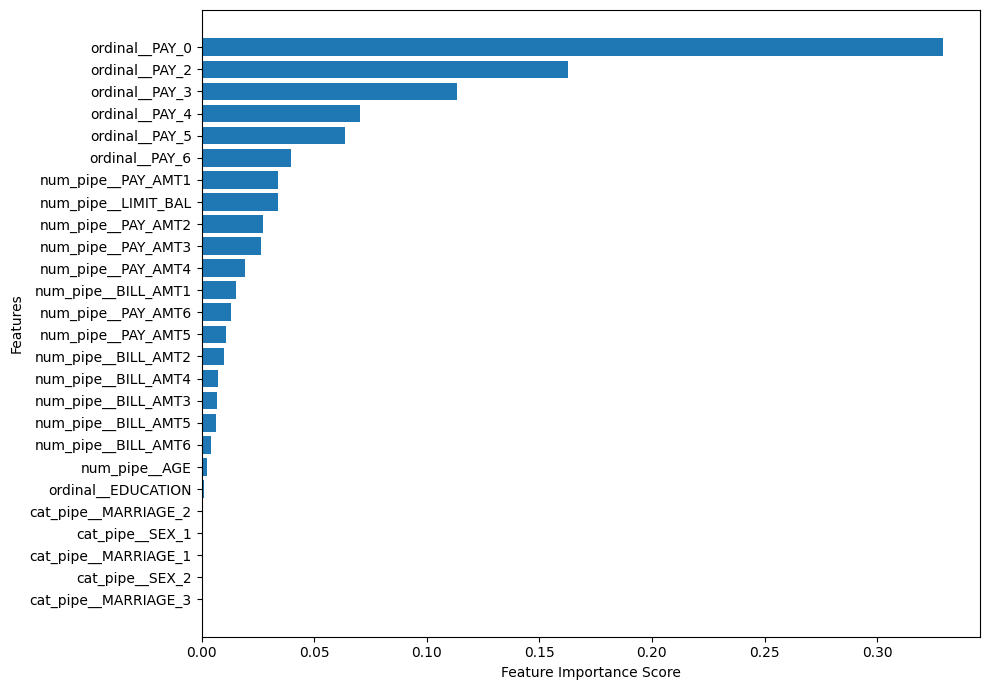

In [77]:
plt.figure(figsize=(10, 7))
plt.barh(rf_df_importance_sorted['Feature_names'], rf_df_importance_sorted['Feature_importance'])
plt.ylabel("Features")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

From this graph, we note that marriage, sex, and education do not contribute much, which matches our EDA. However, sex and marriage are demographic features, so by removing them, we lose the ability to analyse whether the model treated different groups differently. This could be an ethical issue; however, for this project, I will focus only on whether they improve predictive performance. In a real production setting, we would likely retain demographic features for fairness auditing.

Now we will explore our model’s capabilities using a reduced feature set and evaluate how it performs in comparison with the full feature set. Education, age, sex, and marriage will be removed, as they scored the lowest in feature importance.

In [79]:
# Reduced feature list

red_num_cols = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6' ]


red_ordinal_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

red_preprocessor = ColumnTransformer(transformers=[
    ('red_num_cols', num_pipe, red_num_cols),
    ('red_ordinal', 'passthrough', red_ordinal_cols) # ordinal columns are just passed through 
])

In [80]:
# new model instance using tuned hyperparams
rf_clf_red = RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=500)

# reduced feature pipe
red_rf_pipe = Pipeline(steps=[
    ('red_col_trans', red_preprocessor),
    ('rf_clf_red', rf_clf_red)
])

In [81]:
red_rf_fit = red_rf_pipe.fit(X_train, y_train)
red_rf_pred = red_rf_fit.predict(X_test)

red_rf_report = classification_report(y_test, red_rf_pred)
print(red_rf_report)

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      4600
           1       0.51      0.61      0.56      1321

    accuracy                           0.78      5921
   macro avg       0.70      0.72      0.71      5921
weighted avg       0.80      0.78      0.79      5921



The results are identical with the reduced feature set, which confirms that the feature importance scores were correct. The model is entirely driven by the repayment status and financial amount features. Moving forward, we can work with the reduced set, as fewer features mean a simpler, faster model that is easier to explain.

array(['red_num_cols__LIMIT_BAL', 'red_num_cols__BILL_AMT1',
       'red_num_cols__BILL_AMT2', 'red_num_cols__BILL_AMT3',
       'red_num_cols__BILL_AMT4', 'red_num_cols__BILL_AMT5',
       'red_num_cols__BILL_AMT6', 'red_num_cols__PAY_AMT1',
       'red_num_cols__PAY_AMT2', 'red_num_cols__PAY_AMT3',
       'red_num_cols__PAY_AMT4', 'red_num_cols__PAY_AMT5',
       'red_num_cols__PAY_AMT6', 'red_ordinal__PAY_0',
       'red_ordinal__PAY_2', 'red_ordinal__PAY_3', 'red_ordinal__PAY_4',
       'red_ordinal__PAY_5', 'red_ordinal__PAY_6'], dtype=object)